In [1]:
# Source inspiration: https://www.kaggle.com/bhaveshsk/getting-started-with-titanic-dataset/data
# This notebook intentionally keeps a notebook-style workflow so you can
# practice deciding what should stay exploratory and what should move into
# reusable Python functions.

from pathlib import Path

# Data analysis and wrangling
import pandas as pd
import numpy as np

# Data visualization for quick exploratory checks
import seaborn as sns
import matplotlib.pyplot as plt

# Notebook-style baseline models; the refactored Python script will use a
# cleaner, smaller model comparison workflow.
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# Explicit category orders keep seaborn plots stable and silence ordering warnings.
EMBARKED_ORDER = ["S", "C", "Q"]
SEX_ORDER = ["male", "female"]
PCLASS_ORDER = [1, 2, 3]

## Exercise: Refactor Notebook Code into a Python Script

**What this notebook is:** a notebook-style baseline workflow with quick checks,
plots, and feature-engineering steps mixed together.

**What your refactor should do:** keep the stable logic, simplify the flow, and
move the reusable parts into script functions.

@TODO:
1. Complete `src/titanic_refactoring/titanic_exercise.py`.
2. Keep reusable steps such as loading data, preprocessing, and model
   comparison in the script.
3. Leave notebook-only exploration, plots, and quick displays here.
4. Compare your result against `src/titanic_refactoring/titanic_solution.py`.

**Keep this distinction in mind as you read:**
- Notebook-style code is often useful for exploration.
- Script code should be easier to rerun, test, and reuse.

Starter file: `src/titanic_refactoring/titanic_exercise.py`  
Reference solution: `src/titanic_refactoring/titanic_solution.py`


## Visual Guide: Titanic Baseline Workflow

```mermaid
flowchart TD
    A["Load Titanic data"]
    B["Notebook exploration"]
    C["Preprocessing candidates"]
    D["Script preprocess()"]
    E["Model comparison"]
    F["Ranked results table"]

    A --> B --> C --> D --> E --> F
```


Loading the local Titanic CSV into a DataFrame.

To keep the rest of the notebook close to the original Kaggle-style flow, the
next cell also creates a notebook-style `test_df` copy without the target
column. That copy is only a teaching convenience for this notebook. The Python
script you refactor to later should use a cleaner train/validation workflow.


In [2]:
candidate_paths = [Path("../data/titanic.csv"), Path("data/titanic.csv")]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find data/titanic.csv from this notebook.")

train_df = pd.read_csv(data_path)

# This repository only includes one Titanic CSV. To keep the notebook close to
# the original tutorial structure, create a no-target copy that plays the role
# of a notebook-style test set.
test_df = train_df.drop(columns=["Survived"]).copy()
combine = [train_df, test_df]

print(f"Loaded Titanic data from: {data_path}")
print(f"train_df shape: {train_df.shape}")
print(f"test_df shape: {test_df.shape}")

Loaded Titanic data from: ..\data\titanic.csv
train_df shape: (891, 12)
test_df shape: (891, 11)


- Printing DataFrame column names helps you understand available features.
- This is also useful for deciding which columns are likely informative for modeling.


In [3]:
print(train_df.columns.values)

<StringArray>
['PassengerId',    'Survived',      'Pclass',        'Name',         'Sex',
         'Age',       'SibSp',       'Parch',      'Ticket',        'Fare',
       'Cabin',    'Embarked']
Length: 12, dtype: str


`DataFrame.head()` shows the first rows and helps with quick sanity checks.


In [4]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


`DataFrame.tail()` shows the last rows and helps detect formatting issues near the end of a file.


In [5]:
train_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
train_df.info()
print("#" * 50)
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
##################################################
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null

`DataFrame.describe()` summarizes numeric columns (count, mean, std, percentiles), which is useful for quick EDA checks.


In [7]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
train_df.describe(include=["object", "string"])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


### Exploratory Checks Before Refactoring

The next few cells are useful because they help us decide which columns look
promising. They are also a reminder that not every helpful notebook cell needs
to become part of the final Python script.


These grouped summaries are classic notebook-style EDA.

They help us decide which columns carry signal before we choose what belongs in
reusable preprocessing code.

Here, we compute average survival rate by passenger class:


In [9]:
# Compare passenger class against survival to see whether class should be
# treated as an informative modeling feature.
train_df[["Pclass", "Survived"]].groupby(["Pclass"], as_index=False).mean().sort_values(
    by="Survived", ascending=False
)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


Here, we compute average survival rate by passenger sex.

This is still exploration, but it often points toward transformations we will
keep in the refactored script.


In [10]:
# Comparing survival by sex helps motivate encoding this categorical
# column later in the workflow.
train_df[["Sex", "Survived"]].groupby(["Sex"], as_index=False).mean().sort_values(
    by="Survived", ascending=False
)

,Sex,Survived
0,female,0.742038
1,male,0.188908


Here, we compute average survival rate by `SibSp` (number of siblings/spouses aboard the Titanic):


In [11]:
# `SibSp` may capture social context that affects survival, so we inspect
# it before engineering broader family-based features.
train_df[["SibSp", "Survived"]].groupby(["SibSp"], as_index=False).mean().sort_values(
    by="Survived", ascending=False
)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


Here, we compute average survival rate by `Parch` (number of parents/children aboard the Titanic):


In [12]:
# `Parch` provides a complementary family signal that we may combine with
# `SibSp` during feature engineering.
train_df[["Parch", "Survived"]].groupby(["Parch"], as_index=False).mean().sort_values(
    by="Survived", ascending=False
)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


A histogram of `Age` vs. `Survived` helps visualize whether survival
probability differs across age ranges.

Plots like this are useful notebook exploration, but they usually stay in the
notebook rather than moving into the final Python module.


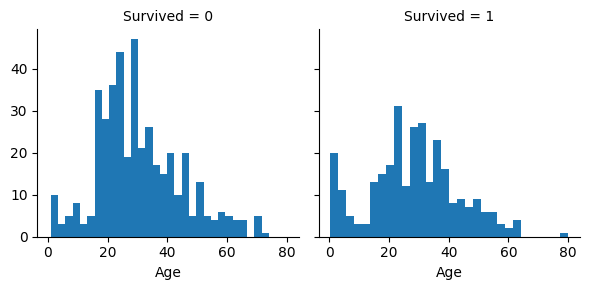

In [13]:
# Quick visual check: do younger and older passengers appear to have
# different survival patterns?
g = sns.FacetGrid(train_df, col="Survived")
g.map(plt.hist, "Age", bins=30)

This plot also suggests that passenger class was associated with survival probability.


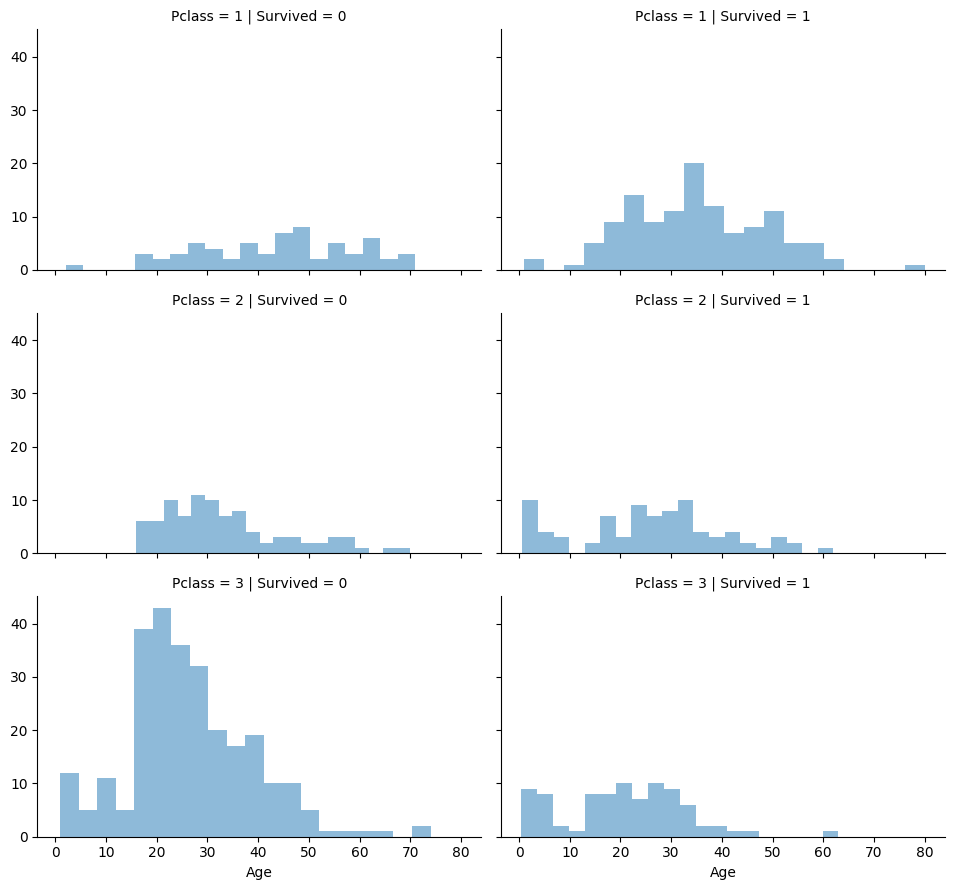

In [14]:
grid = sns.FacetGrid(train_df, col="Survived", row="Pclass", height=3, aspect=1.6)
grid.map(plt.hist, "Age", alpha=0.5, bins=20)
grid.add_legend()

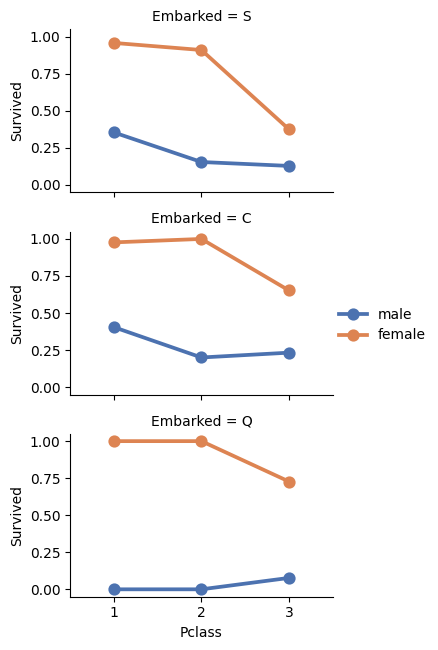

In [15]:
grid = sns.FacetGrid(
    train_df, row="Embarked", row_order=EMBARKED_ORDER, height=2.2, aspect=1.6
)
grid.map_dataframe(
    sns.pointplot,
    x="Pclass",
    y="Survived",
    hue="Sex",
    order=PCLASS_ORDER,
    hue_order=SEX_ORDER,
    palette="deep",
    errorbar=None,
)
grid.add_legend()

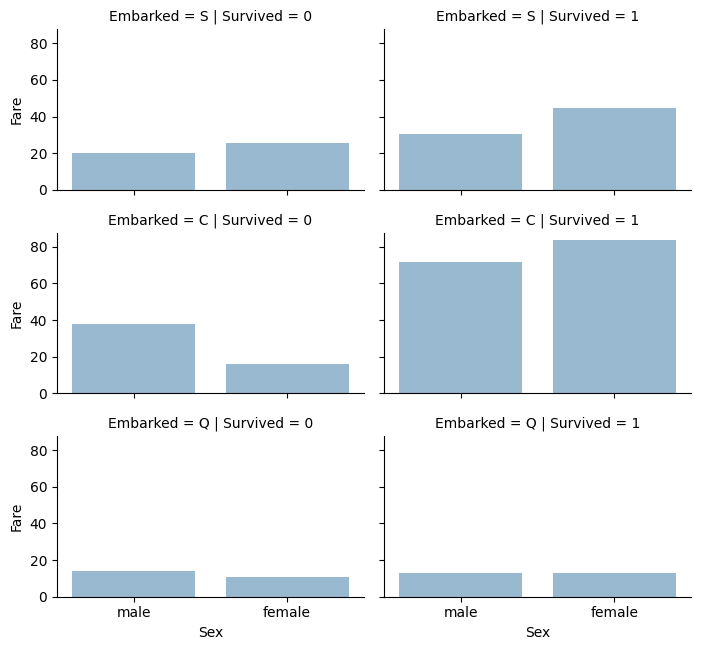

In [16]:
grid = sns.FacetGrid(
    train_df,
    row="Embarked",
    col="Survived",
    row_order=EMBARKED_ORDER,
    height=2.2,
    aspect=1.6,
)
grid.map_dataframe(
    sns.barplot,
    x="Sex",
    y="Fare",
    order=SEX_ORDER,
    errorbar=None,
    alpha=0.5,
)
grid.add_legend()

### Feature Engineering Candidates

The next block contains the densest transformation logic in the notebook. This
is exactly the kind of code worth reading carefully, commenting clearly,
and then simplify when moving it into reusable Python functions.


In [17]:
# Drop columns with very sparse or messy text values before feature
# engineering the remaining fields.
print("Before:", train_df.shape, test_df.shape, combine[0].shape, combine[1].shape)

train_df = train_df.drop(["Ticket", "Cabin"], axis=1)
test_df = test_df.drop(["Ticket", "Cabin"], axis=1)
combine = [train_df, test_df]

print("After:", train_df.shape, test_df.shape, combine[0].shape, combine[1].shape)

Before: (891, 12) (891, 11) (891, 12) (891, 11)
After: (891, 10) (891, 9) (891, 10) (891, 9)


In [18]:
# Extract titles from passenger names. This is a good example of logic
# that might deserve its own helper function in a real preprocessing module.
for dataset in combine:
    dataset["Title"] = dataset.Name.str.extract(" ([A-Za-z]+)\.", expand=False)

pd.crosstab(train_df["Title"], train_df["Sex"])

Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [19]:
# Collapse infrequent titles into a smaller set so the feature is easier
# to model and explain.
for dataset in combine:
    dataset["Title"] = dataset["Title"].replace(
        [
            "Lady",
            "Countess",
            "Capt",
            "Col",
            "Don",
            "Dr",
            "Major",
            "Rev",
            "Sir",
            "Jonkheer",
            "Dona",
        ],
        "Rare",
    )

    dataset["Title"] = dataset["Title"].replace("Mlle", "Miss")
    dataset["Title"] = dataset["Title"].replace("Ms", "Miss")
    dataset["Title"] = dataset["Title"].replace("Mme", "Mrs")

train_df[["Title", "Survived"]].groupby(["Title"], as_index=False).mean()

,Title,Survived
0,Master,0.575000
1,Miss,0.702703
2,Mr,0.156673
3,Mrs,0.793651
4,Rare,0.347826


In [20]:
# Map cleaned titles to compact numeric codes so the notebook can keep a
# fully numeric feature matrix later on.
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
for dataset in combine:
    dataset["Title"] = dataset["Title"].map(title_mapping)
    dataset["Title"] = dataset["Title"].fillna(0)

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,3
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,3
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,1


In [21]:
# After extracting the useful signal from `Name`, we can drop the raw
# text column. `PassengerId` stays only in the notebook-style test copy so a
# submission-like table can still be built later.
train_df = train_df.drop(["Name", "PassengerId"], axis=1)
test_df = test_df.drop(["Name"], axis=1)
combine = [train_df, test_df]
train_df.shape, test_df.shape

((891, 9), (891, 9))

In [22]:
# Convert sex labels to numeric values so classical sklearn models can
# consume the feature directly.
for dataset in combine:
    dataset["Sex"] = dataset["Sex"].map({"female": 1, "male": 0}).astype(int)

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,22.0,1,0,7.2500,S,1
1,1,1,1,38.0,1,0,71.2833,C,3
2,1,3,1,26.0,0,0,7.9250,S,2
3,1,1,1,35.0,1,0,53.1000,S,3
4,0,3,0,35.0,0,0,8.0500,S,1


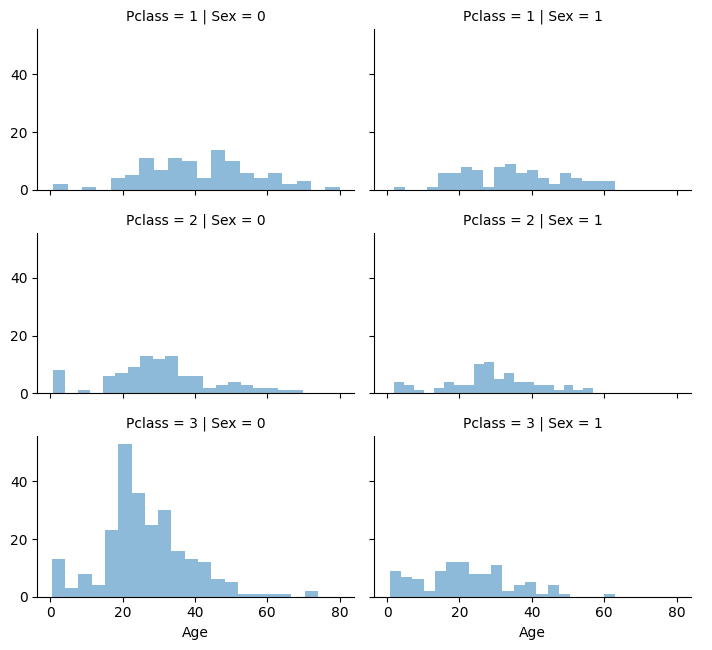

In [23]:
grid = sns.FacetGrid(train_df, row="Pclass", col="Sex", height=2.2, aspect=1.6)
grid.map(plt.hist, "Age", alpha=0.5, bins=20)
grid.add_legend()

### A Dense Example: Group-Based Age Imputation

This section is worth slowing down for. The rule is more complex than a single
`fillna(median)` call, so it is a good example of notebook code that benefits
from careful comments before you refactor it.


In [24]:
# Store median age guesses for each `(Sex, Pclass)` group. This makes the
# imputation rule more specific than using one global age median.
guess_ages = np.zeros((2, 3))
guess_ages

array([[0., 0., 0.],
       [0., 0., 0.]])

In [ ]:
for dataset in combine:
    for i in range(0, 2):
        for j in range(0, 3):
            guess_df = dataset[(dataset["Sex"] == i) & (dataset["Pclass"] == j + 1)][
                "Age"
            ].dropna()

            # Use the group median because it is robust and easy to justify in
            # this baseline example.
            age_guess = guess_df.median()

            # Round to the nearest 0.5 first, then cast to int later so the
            # filled ages look less arbitrary in the intermediate notebook view.
            guess_ages[i, j] = int(2 * age_guess  + 0.5) / 2 
 
    for i in range(0, 2):
        for j in range(0, 3):
            dataset.loc[
                (dataset.Age.isnull()) & (dataset.Sex == i) & (dataset.Pclass == j + 1),
                "Age"] = guess_ages[i, j]

    dataset["Age"] = dataset["Age"].astype(int)

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,22,1,0,7.2500,S,1
1,1,1,1,38,1,0,71.2833,C,3
2,1,3,1,26,0,0,7.9250,S,2
3,1,1,1,35,1,0,53.1000,S,3
4,0,3,0,35,0,0,8.0500,S,1


In [26]:
train_df["AgeBand"] = pd.cut(train_df["Age"], 5)
train_df[["AgeBand", "Survived"]].groupby(
    ["AgeBand"], as_index=False
).mean().sort_values(by="AgeBand", ascending=True)

,AgeBand,Survived
0,"(-0.08, 16.0]",0.550000
1,"(16.0, 32.0]",0.337374
2,"(32.0, 48.0]",0.412037
3,"(48.0, 64.0]",0.434783
4,"(64.0, 80.0]",0.090909


In [27]:
# Bucket age into coarse groups. This is a notebook-style feature choice
# that can be kept, simplified, or dropped in the script.
for dataset in combine:
    dataset.loc[dataset["Age"] <= 16, "Age"] = 0
    dataset.loc[(dataset["Age"] > 16) & (dataset["Age"] <= 32), "Age"] = 1
    dataset.loc[(dataset["Age"] > 32) & (dataset["Age"] <= 48), "Age"] = 2
    dataset.loc[(dataset["Age"] > 48) & (dataset["Age"] <= 64), "Age"] = 3
    dataset.loc[dataset["Age"] > 64, "Age"] = 4
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,AgeBand
0,0,3,0,1,1,0,7.2500,S,1,"(16.0, 32.0]"
1,1,1,1,2,1,0,71.2833,C,3,"(32.0, 48.0]"
2,1,3,1,1,0,0,7.9250,S,2,"(16.0, 32.0]"
3,1,1,1,2,1,0,53.1000,S,3,"(32.0, 48.0]"
4,0,3,0,2,0,0,8.0500,S,1,"(32.0, 48.0]"


In [28]:
train_df = train_df.drop(["AgeBand"], axis=1)
combine = [train_df, test_df]
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,1,1,0,7.2500,S,1
1,1,1,1,2,1,0,71.2833,C,3
2,1,3,1,1,0,0,7.9250,S,2
3,1,1,1,2,1,0,53.1000,S,3
4,0,3,0,2,0,0,8.0500,S,1


In [29]:
# Combine sibling/spouse and parent/child counts into one broader family
# size feature.
for dataset in combine:
    dataset["FamilySize"] = dataset["SibSp"] + dataset["Parch"] + 1

train_df[["FamilySize", "Survived"]].groupby(
    ["FamilySize"], as_index=False
).mean().sort_values(by="Survived", ascending=False)

,FamilySize,Survived
3,4,0.724138
2,3,0.578431
1,2,0.552795
6,7,0.333333
0,1,0.303538
4,5,0.200000
5,6,0.136364
7,8,0.000000
8,11,0.000000


In [30]:
# Turn family size into a simpler binary signal: traveling alone or not.
for dataset in combine:
    dataset["IsAlone"] = 0
    dataset.loc[dataset["FamilySize"] == 1, "IsAlone"] = 1

train_df[["IsAlone", "Survived"]].groupby(["IsAlone"], as_index=False).mean()

,IsAlone,Survived
0,0,0.505650
1,1,0.303538


In [31]:
# After engineering the family-based features, drop the original columns
# if we no longer want to model them directly.
train_df = train_df.drop(["Parch", "SibSp", "FamilySize"], axis=1)
test_df = test_df.drop(["Parch", "SibSp", "FamilySize"], axis=1)
combine = [train_df, test_df]

train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone
0,0,3,0,1,7.2500,S,1,0
1,1,1,1,2,71.2833,C,3,0
2,1,3,1,1,7.9250,S,2,1
3,1,1,1,2,53.1000,S,3,0
4,0,3,0,2,8.0500,S,1,1


In [32]:
# Interaction features combine two signals into one column. Here we mix
# age band and passenger class.
for dataset in combine:
    dataset["Age*Class"] = dataset.Age * dataset.Pclass

train_df.loc[:, ["Age*Class", "Age", "Pclass"]].head(10)

,Age*Class,Age,Pclass
0,3,1,3
1,2,2,1
2,3,1,3
3,2,2,1
4,6,2,3
5,3,1,3
6,3,3,1
7,0,0,3
8,3,1,3
9,0,0,2


In [33]:
# `Embarked` has only a few missing values, so using the most frequent
# port is a quick and explainable notebook baseline.
freq_port = train_df.Embarked.dropna().mode()[0]
freq_port

'S'

In [34]:
# Fill missing embarkation values before encoding the column numerically.
for dataset in combine:
    dataset["Embarked"] = dataset["Embarked"].fillna(freq_port)

train_df[["Embarked", "Survived"]].groupby(
    ["Embarked"], as_index=False
).mean().sort_values(by="Survived", ascending=False)

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.339009


In [35]:
# Map the cleaned embarkation values to integers to keep the feature
# matrix numeric for the notebook baseline.
for dataset in combine:
    dataset["Embarked"] = dataset["Embarked"].map({"S": 0, "C": 1, "Q": 2}).astype(int)

train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone,Age*Class
0,0,3,0,1,7.2500,0,1,0,3
1,1,1,1,2,71.2833,1,3,0,2
2,1,3,1,1,7.9250,0,2,1,3
3,1,1,1,2,53.1000,0,3,0,2
4,0,3,0,2,8.0500,0,1,1,6


In [36]:
# The notebook-style test copy may contain missing fares in other Titanic
# variants, so we guard the fill step here as a reusable pattern.
test_df["Fare"] = test_df["Fare"].fillna(test_df["Fare"].dropna().median())
test_df.head()

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone,Age*Class
0,1,3,0,1,7.2500,0,1,0,3
1,2,1,1,2,71.2833,1,3,0,2
2,3,3,1,1,7.9250,0,2,1,3
3,4,1,1,2,53.1000,0,3,0,2
4,5,3,0,2,8.0500,0,1,1,6


In [37]:
# Inspect fare quartiles before turning a continuous feature into a few
# coarse bins.
train_df["FareBand"] = pd.qcut(train_df["Fare"], 4)
train_df[["FareBand", "Survived"]].groupby(
    ["FareBand"], as_index=False
).mean().sort_values(by="FareBand", ascending=True)

,FareBand,Survived
0,"(-0.001, 7.91]",0.197309
1,"(7.91, 14.454]",0.303571
2,"(14.454, 31.0]",0.454955
3,"(31.0, 512.329]",0.581081


In [38]:
# Apply the fare buckets to both DataFrames, then drop the temporary
# helper column used for inspection.
for dataset in combine:
    dataset.loc[dataset["Fare"] <= 7.91, "Fare"] = 0
    dataset.loc[(dataset["Fare"] > 7.91) & (dataset["Fare"] <= 14.454), "Fare"] = 1
    dataset.loc[(dataset["Fare"] > 14.454) & (dataset["Fare"] <= 31), "Fare"] = 2
    dataset.loc[dataset["Fare"] > 31, "Fare"] = 3
    dataset["Fare"] = dataset["Fare"].astype(int)

train_df = train_df.drop(["FareBand"], axis=1)
combine = [train_df, test_df]

train_df.head(10)

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone,Age*Class
0,0,3,0,1,0,0,1,0,3
1,1,1,1,2,3,1,3,0,2
2,1,3,1,1,1,0,2,1,3
3,1,1,1,2,3,0,3,0,2
4,0,3,0,2,1,0,1,1,6
5,0,3,0,1,1,2,1,1,3
6,0,1,0,3,3,0,1,1,3
7,0,3,0,0,2,0,4,0,0
8,1,3,1,1,1,0,3,0,3
9,1,2,1,0,2,1,3,0,0


In [39]:
test_df.head(10)

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone,Age*Class
0,1,3,0,1,0,0,1,0,3
1,2,1,1,2,3,1,3,0,2
2,3,3,1,1,1,0,2,1,3
3,4,1,1,2,3,0,3,0,2
4,5,3,0,2,1,0,1,1,6
5,6,3,0,1,1,2,1,1,3
6,7,1,0,3,3,0,1,1,3
7,8,3,0,0,2,0,4,0,0
8,9,3,1,1,1,0,3,0,3
9,10,2,1,0,2,1,3,0,0


### Notebook-Style Model Comparison

The next cells keep the original notebook habit of fitting several models one
by one and comparing quick scores. In the script version, we want the same idea
but with a cleaner function boundary and a proper validation split.


### Visual Guide: Script-Friendly Model Evaluation

```mermaid
flowchart TD
    A["Preprocessed feature matrix"]
    B["Train and validation split"]
    C["Fit baseline models"]
    D["Score on validation data"]
    E["Sort into a comparison table"]

    A --> B --> C --> D --> E
```


In [40]:
# Build the modeling matrices from the notebook-transformed DataFrames.
# In the refactored Python script, this responsibility should be wrapped in a
# helper with explicit inputs and outputs.
X_train = train_df.drop("Survived", axis=1)
Y_train = train_df["Survived"]
X_test = test_df.drop("PassengerId", axis=1).copy()
X_train.shape, Y_train.shape, X_test.shape

((891, 8), (891,), (891, 8))

In [41]:
# Fit one baseline model at a time so the notebook can inspect results
# interactively.
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, Y_train)
Y_pred = logreg.predict(X_test)
acc_log = round(logreg.score(X_train, Y_train) * 100, 2)
acc_log

81.37

In [42]:
coeff_df = pd.DataFrame(train_df.columns.delete(0))
coeff_df.columns = ["Feature"]
coeff_df["Correlation"] = pd.Series(logreg.coef_[0])

coeff_df.sort_values(by="Correlation", ascending=False)

,Feature,Correlation
1,Sex,2.201033
5,Title,0.406095
4,Embarked,0.276739
6,IsAlone,0.185767
7,Age*Class,-0.050246
3,Fare,-0.071894
2,Age,-0.469586
0,Pclass,-1.200216


In [43]:
svc = SVC()
svc.fit(X_train, Y_train)
Y_pred = svc.predict(X_test)
acc_svc = round(svc.score(X_train, Y_train) * 100, 2)
acc_svc

82.83

In [44]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, Y_train)
Y_pred = knn.predict(X_test)
acc_knn = round(knn.score(X_train, Y_train) * 100, 2)
acc_knn

82.83

In [45]:
gaussian = GaussianNB()
gaussian.fit(X_train, Y_train)
Y_pred = gaussian.predict(X_test)
acc_gaussian = round(gaussian.score(X_train, Y_train) * 100, 2)
acc_gaussian

76.88

In [46]:
linear_svc = LinearSVC(max_iter=5000, random_state=42)
linear_svc.fit(X_train, Y_train)
Y_pred = linear_svc.predict(X_test)
acc_linear_svc = round(linear_svc.score(X_train, Y_train) * 100, 2)
acc_linear_svc

79.46

In [47]:
sgd = SGDClassifier(random_state=42)
sgd.fit(X_train, Y_train)
Y_pred = sgd.predict(X_test)
acc_sgd = round(sgd.score(X_train, Y_train) * 100, 2)
acc_sgd

76.88

In [48]:
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, Y_train)
Y_pred = decision_tree.predict(X_test)
acc_decision_tree = round(decision_tree.score(X_train, Y_train) * 100, 2)
acc_decision_tree

86.64

In [49]:
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, Y_train)
Y_pred = random_forest.predict(X_test)
acc_random_forest = round(random_forest.score(X_train, Y_train) * 100, 2)
acc_random_forest

86.64

In [50]:
# Compare model scores in one table. This notebook uses training-set
# scores, which is convenient for exploration but not ideal for final
# evaluation. The refactored script should improve this by using a proper
# train/validation split.
models = pd.DataFrame(
    {
        "Model": [
            "Support Vector Machines",
            "KNN",
            "Logistic Regression",
            "Random Forest",
            "Naive Bayes",
            "Stochastic Gradient Descent",
            "Linear SVC",
            "Decision Tree",
        ],
        "Score": [
            acc_svc,
            acc_knn,
            acc_log,
            acc_random_forest,
            acc_gaussian,
            acc_sgd,
            acc_linear_svc,
            acc_decision_tree,
        ],
    }
)
models.sort_values(by="Score", ascending=False)

,Model,Score
3,Random Forest,86.64
7,Decision Tree,86.64
1,KNN,82.83
0,Support Vector Machines,82.83
2,Logistic Regression,81.37
6,Linear SVC,79.46
5,Stochastic Gradient Descent,76.88
4,Naive Bayes,76.88


### Handoff to the Python Exercise

At this point, you should be able to point to:

- notebook-only exploration that should stay here,
- reusable preprocessing logic that belongs in `preprocess()`, and
- model-comparison logic that belongs in `train_and_score_models()`.

Now implement the cleaner, script-based version in
`src/titanic_refactoring/titanic_exercise.py` and compare your result with
`src/titanic_refactoring/titanic_solution.py`.


In [51]:
# Build a submission-style table to mirror the original notebook flow.
# In the refactored script, prefer returning clean objects instead of writing
# files as a side effect from deep inside helper logic.
submission = pd.DataFrame({"PassengerId": test_df["PassengerId"], "Survived": Y_pred})
submission.head()

,PassengerId,Survived
0,1,0
1,2,1
2,3,0
3,4,1
4,5,0
